<a href="https://colab.research.google.com/github/lauratpaes/Anna-Clara-_-Laura_-Lavinia/blob/main/tarefa7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 7 - Bioestatística

###Anna Clara Tonial 17097091
###Laura Tavares Paes 17097601
###Lavinia Ramos 17081100

In [6]:
import pandas as pd
df = pd.read_csv("Tarefa_Semana4.csv", sep='\t')
display(df)

,pH,Biomass,Species
0,high,0.469297,30
1,high,1.730870,39
2,high,2.089778,44
3,high,3.925787,35
4,high,4.366793,25
...,...,...,...
85,low,2.325963,8
86,low,2.995706,12
87,low,3.538199,14
88,low,4.364541,7


In [7]:

ph_mapping = {
    'low': 1,
    'medium': 2,
    'high': 3
}

df['pH_numeric'] = df['pH'].map(ph_mapping)

display(df)

,pH,Biomass,Species,pH_numeric
0,high,0.469297,30,3.0
1,high,1.730870,39,3.0
2,high,2.089778,44,3.0
3,high,3.925787,35,3.0
4,high,4.366793,25,3.0
...,...,...,...,...
85,low,2.325963,8,1.0
86,low,2.995706,12,1.0
87,low,3.538199,14,1.0
88,low,4.364541,7,1.0


#Gráfico entre número de espécies e quantidade de biomassa

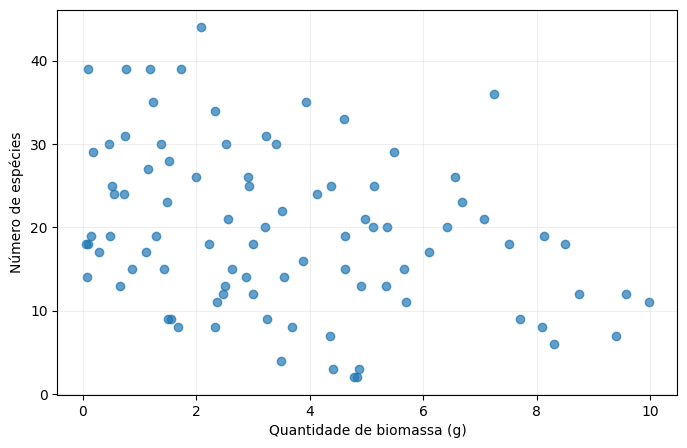

In [8]:
import matplotlib.pyplot as plt

x = df["Biomass"]
y = df["Species"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Quantidade de biomassa (g)")
plt.ylabel("Número de espécies")
plt.grid(alpha=0.2)
plt.show()

Pergunta 1. Gráfico representado acima.

Pergunta 2. O gráfico sugere uma associação negativa.

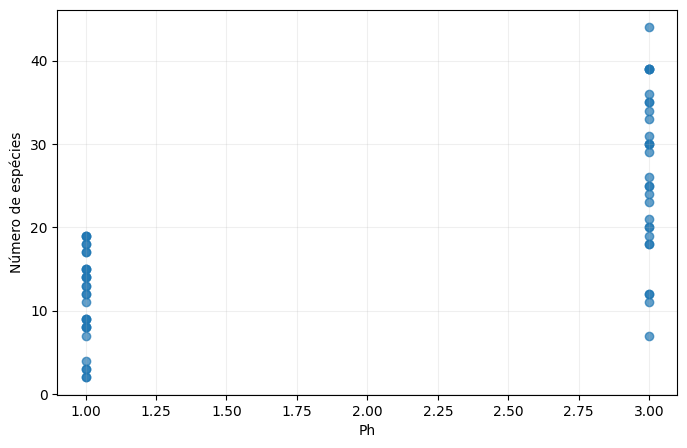

In [9]:

x = df["pH_numeric"]
y = df["Species"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Ph")
plt.ylabel("Número de espécies")
plt.grid(alpha=0.2)
plt.show()

Pergunta 3. Sim, existe uma evidência de associação linear positiva.

In [13]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = df['Biomass'].values.reshape(-1, 1)
y = df['Species'].values
model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(f"Coeficiente (inclinação): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Coeficiente (inclinação): -1.19
Intercepto: 23.68


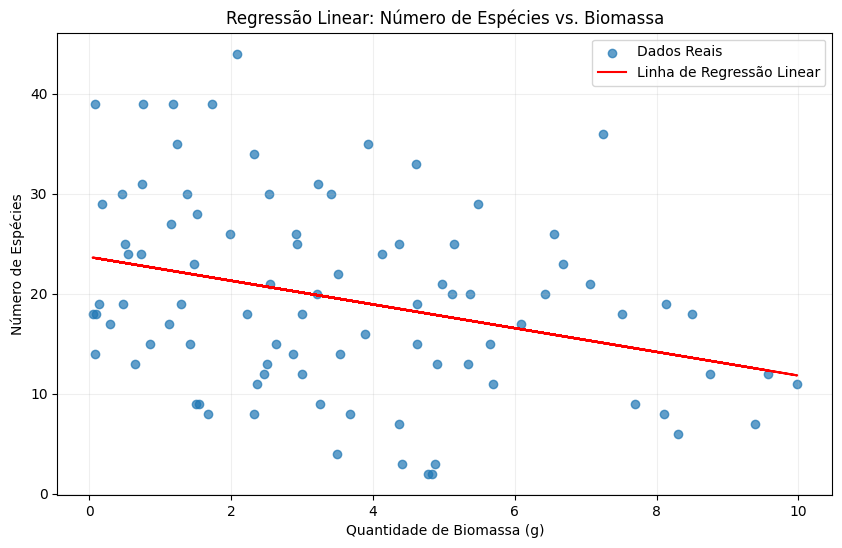

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

X = df['Biomass'].values.reshape(-1, 1)
y = df['Species'].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, label='Dados Reais')
plt.plot(X, y_pred, color='red', label='Linha de Regressão Linear')
plt.xlabel("Quantidade de Biomassa (g)")
plt.ylabel("Número de Espécies")
plt.title("Regressão Linear: Número de Espécies vs. Biomassa")
plt.grid(alpha=0.2)
plt.legend()
plt.show()

Pergunta 4. Modelos representados acima.

In [16]:
from sklearn.linear_model import LinearRegression

df_reg = df.dropna(subset=['pH_numeric'])

X_ph = df_reg['pH_numeric'].values.reshape(-1, 1)
y_species = df_reg['Species'].values

model_ph = LinearRegression()
model_ph.fit(X_ph, y_species)

coef_ph = model_ph.coef_[0]
intercept_ph = model_ph.intercept_

display(f"Coeficiente (inclinação): {coef_ph:.2f}")
display(f"Intercepto: {intercept_ph:.2f}")
display(f"Equação da reta de regressão: Número de Espécies = {coef_ph:.2f} * pH_numeric + {intercept_ph:.2f}")

'Coeficiente (inclinação): 7.62'

'Intercepto: 3.95'

'Equação da reta de regressão: Número de Espécies = 7.62 * pH_numeric + 3.95'

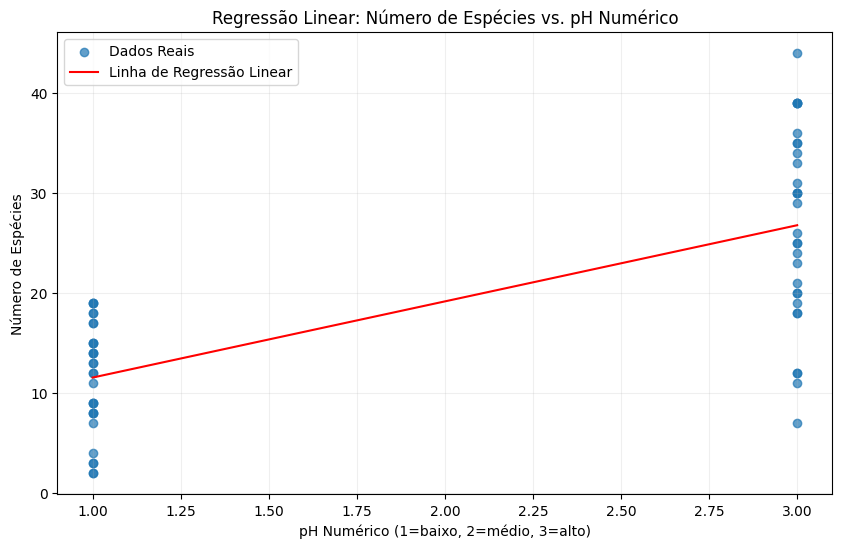

In [18]:
import matplotlib.pyplot as plt

y_pred_ph = model_ph.predict(X_ph)

plt.figure(figsize=(10, 6))
plt.scatter(X_ph, y_species, alpha=0.7, label='Dados Reais')
plt.plot(X_ph, y_pred_ph, color='red', label='Linha de Regressão Linear')
plt.xlabel("pH Numérico (1=baixo, 2=médio, 3=alto)")
plt.ylabel("Número de Espécies")
plt.title("Regressão Linear: Número de Espécies vs. pH Numérico")
plt.grid(alpha=0.2)
plt.legend()
plt.show()


Pergunta 5. A equação da reta de regressão que relaciona número de espécies a quantidade de ph é: número de espécies = 7.62(ph) + 3.95.

In [19]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = df['Biomass'].values.reshape(-1, 1)
y = df['Species'].values

model = LinearRegression()
model.fit(X, y)

print(f"Coeficiente (inclinação): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

y_pred = model.predict(X)


Coeficiente (inclinação): -1.19
Intercepto: 23.68


Pergunta 6. O valor do intercepto de regressão é de 23.68. Por ser o valor de y quando x=0, podemos interpretar que teriamos aproximadamente 23 espécies com biomassa igual a 0 gramas, mas, como predição, isso não se aplica ao exemplo real, já que não é possível o indivíduo vegetal existir sem possuir biomassa.

Pergunta 7. O coeficiente de inclinação é de -1.19. Isso significa que a cada 1 unidade de biomassa que aumenta, há um decréscimo de 1.19 em número de espécies, por ser uma associação negativa.

In [20]:
pearson_corr = df['Biomass'].corr(df['Species'])
print(f"O coeficiente de correlação de Pearson entre Biomassa e Número de Espécies é: {pearson_corr:.2f}")

O coeficiente de correlação de Pearson entre Biomassa e Número de Espécies é: -0.32


Pergunta 8. Não, a quantidade de biomassa não apresenta um efeito significativo sobre o número de espécies de plantas, pois o coeficiente de correlação de Pearson de -0.32 indica uma associação fraca.

In [21]:
r_squared_ph = model_ph.score(X_ph, y_species)
display(f"O coeficiente de determinação (R-quadrado) para o modelo de pH é: {r_squared_ph:.2f}")

'O coeficiente de determinação (R-quadrado) para o modelo de pH é: 0.50'

Pergunta 9. O coeficiente de determinação usando o modelo de regressão deu 0.50. Isso significa que cerca de 50% da variação em número de espécies pode ser explicada pelo ph.

Pergunta 10. Não, pois a correlção entree stas variáveis resultou em -0.32, uma valor que representa associação fraca.


In [22]:
pearson_corr_ph = df['pH_numeric'].corr(df['Species'])
display(f"O coeficiente de correlação de Pearson entre pH e Número de Espécies é: {pearson_corr_ph:.2f}")

'O coeficiente de correlação de Pearson entre pH e Número de Espécies é: 0.70'

Pergunta 11. A correlação linear de Pearson entre ph e número de espécies possui intensidade de 0.70, valor alto que mostra associação forte e de direcionamento linear crescente.